In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import operator
from langgraph.graph.message import add_messages
import os
from langgraph.checkpoint.memory import MemorySaver

In [3]:
os.environ["OPENAI_API_KEY"] = ""

In [4]:
class ChatState(TypedDict):
    # AIMessage, HumanMessage, SystemMessage these are inherit the Basemessage means in the list
    # any type of message will be contain or add the reducer function because we need to merge them.

    # Always use addmessages its same as the operator.add but it is optimize one that working well 
    # with the add_messages.
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
llm = ChatOpenAI()

def chat_node(state: ChatState):

    # take user query from state.
    messages = state['messages']

    # send to the llm
    response = llm.invoke(messages)

    # Response store state.

    return {'messages': [response]}

In [6]:
checkpointer = MemorySaver()

# Create the graph.
graph = StateGraph(ChatState)


# Add nodes

graph.add_node('chat_node', chat_node)


# Add edges.
graph.add_edge(START, 'chat_node') 
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

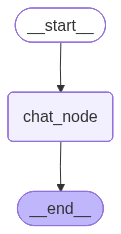

In [7]:
chatbot

In [8]:
# initial State.

# initial_state = {
#     'messages': [HumanMessage(content="what is the HFT arbitrage and ICT concept ??")]
# }

# chatbot.invoke(initial_state)['messages'][-1].content

In [9]:
thread_id = '1'


while True:
    user_message = input('Type here: ')

    print('User: ', user_message)

    if user_message.strip().lower() in  ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    # initial State.

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config)
    print('AI:', response['messages'][-1].content)

User:  


AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

## Till now the chatbot is working fine but the problem is, it cannot remember the history conversation of the user.

For that will use the persistence concept for that to maintain the history means without erase the state at the end, we will store it somewhere.

In [25]:
# This will show the entire history that save into the RAM.
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='dee1a7e8-2cc3-4773-91b1-df24b037bd3a'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CWUgHkydAj4CMegP7RnI5wwhyxxs4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--29acb8b1-2947-4d0a-84da-04e64aea3b70-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), 